# POC — Réplica en Miniatura del Pipeline de Datos
## Sistema de Puntos MyMcDonald's Rewards

**Caso de Estudio 2 — CC3105 — Machine Learning Engineering**

Este notebook replica, en miniatura, la arquitectura de datos del sistema de recompensas de McDonald's:
generación de transacciones crudas (multicanal) → limpieza → filtrado/reglas de negocio → agregación
(saldo de puntos) → una exploración inicial de dónde encajaría un modelo de ML.

Corresponde a las capas **Bronze → Silver → Gold** descritas en el diagrama de arquitectura del proyecto.


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 1. Extracción de Datos (capa Bronze)

Simulamos la llegada de transacciones crudas desde distintos canales: mostrador (POS), kiosco,
drive-thru, app móvil y delivery de terceros. Los datos crudos incluyen ruido típico de un sistema
real: duplicados, montos nulos/negativos y timestamps desordenados.


In [2]:
N_CLIENTES = 200
N_TRANSACCIONES = 3000
CANALES = ["mostrador", "kiosco", "drive_thru", "app", "delivery_terceros"]
PESOS_CANAL = [0.20, 0.10, 0.25, 0.35, 0.10]

def generar_transacciones_crudas(n):
    filas = []
    for i in range(n):
        cliente_id = np.random.randint(1, N_CLIENTES + 1)
        canal = np.random.choice(CANALES, p=PESOS_CANAL)
        monto = round(np.random.gamma(shape=3.0, scale=3.0), 2)  # ticket promedio ~ $9
        # Inyectar ruido típico de datos crudos
        if np.random.rand() < 0.03:
            monto = -monto  # error de captura
        if np.random.rand() < 0.02:
            monto = None    # dato faltante
        ts = datetime(2026, 6, 1) + timedelta(
            days=np.random.randint(0, 30),
            hours=np.random.randint(0, 24),
            minutes=np.random.randint(0, 60),
        )
        filas.append({
            "transaccion_id": f"TXN{i:06d}",
            "cliente_id": cliente_id,
            "canal": canal,
            "monto": monto,
            "timestamp": ts,
        })
    return pd.DataFrame(filas)

raw = generar_transacciones_crudas(N_TRANSACCIONES)

# Inyectar duplicados (evento reenviado por el canal de ingesta) ~2%
dup = raw.sample(frac=0.02, random_state=1)
raw_bronze = pd.concat([raw, dup], ignore_index=True)

# Marcar primeras compras (para el bono de bienvenida)
primera_compra_ids = raw_bronze.sort_values("timestamp").groupby("cliente_id").head(1).index
raw_bronze["es_primera_compra"] = raw_bronze.index.isin(primera_compra_ids)

print(f"Transacciones crudas (Bronze): {len(raw_bronze)} filas")
raw_bronze.head()


Transacciones crudas (Bronze): 3060 filas


,transaccion_id,cliente_id,canal,monto,timestamp,es_primera_compra
0,TXN000000,103,app,10.97,2026-06-11 23:52:00,False
1,TXN000001,100,mostrador,5.35,2026-06-30 05:01:00,False
2,TXN000002,192,delivery_terceros,-17.52,2026-06-10 15:14:00,False
3,TXN000003,190,mostrador,18.15,2026-06-25 02:36:00,False
4,TXN000004,51,app,6.65,2026-06-26 20:01:00,False


## 2. Limpieza (capa Silver)

Aplicamos deduplicación por `transaccion_id`, validación de montos (nulos y negativos) y
normalizamos tipos de datos. Esta capa **no** aplica todavía reglas de negocio del programa de
puntos — solo garantiza que el dato sea confiable.


In [3]:
def limpiar_transacciones(df):
    df = df.copy()
    n_inicial = len(df)

    # Deduplicar por transaccion_id
    df = df.drop_duplicates(subset="transaccion_id")

    # Validar montos: eliminar nulos y negativos (errores de captura)
    montos_invalidos = df["monto"].isna() | (df["monto"] < 0)
    df_invalidos = df[montos_invalidos].copy()
    df = df[~montos_invalidos]

    df["monto"] = df["monto"].astype(float).round(2)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    print(f"Filas iniciales: {n_inicial}")
    print(f"Duplicados removidos: {n_inicial - len(df) - len(df_invalidos)}")
    print(f"Montos inválidos removidos: {len(df_invalidos)}")
    print(f"Filas limpias (Silver): {len(df)}")
    return df.reset_index(drop=True), df_invalidos

silver, descartados = limpiar_transacciones(raw_bronze)
silver.head()


Filas iniciales: 3060
Duplicados removidos: 60
Montos inválidos removidos: 135
Filas limpias (Silver): 2865


,transaccion_id,cliente_id,canal,monto,timestamp,es_primera_compra
0,TXN000000,103,app,10.97,2026-06-11 23:52:00,False
1,TXN000001,100,mostrador,5.35,2026-06-30 05:01:00,False
2,TXN000003,190,mostrador,18.15,2026-06-25 02:36:00,False
3,TXN000004,51,app,6.65,2026-06-26 20:01:00,False
4,TXN000005,84,kiosco,7.85,2026-06-03 13:16:00,False


## 3. Motor de Reglas de Puntos (filtrado + lógica de negocio)

Aquí se aplican las reglas reales del programa, según lo documentado en el diagnóstico:

- **100 puntos por cada $1** gastado en compras elegibles.
- **Bono de bienvenida** de 5,000 puntos en la primera compra.
- **Exclusión**: los pedidos hechos vía **delivery de terceros** no generan puntos.


In [4]:
def calcular_puntos(row):
    if row["canal"] == "delivery_terceros":
        return 0  # exclusión de negocio
    puntos_base = int(row["monto"] * 100)   # 100 pts por $1
    if row["es_primera_compra"]:
        puntos_base += 5000                 # bono de bienvenida
    return puntos_base

silver["puntos_generados"] = silver.apply(calcular_puntos, axis=1)
silver["elegible"] = silver["canal"] != "delivery_terceros"

print(f"Transacciones elegibles: {silver['elegible'].sum()} / {len(silver)}")
silver[["transaccion_id", "cliente_id", "canal", "monto", "es_primera_compra", "puntos_generados"]].head(10)


Transacciones elegibles: 2581 / 2865


,transaccion_id,cliente_id,canal,monto,es_primera_compra,puntos_generados
0,TXN000000,103,app,10.97,False,1097
1,TXN000001,100,mostrador,5.35,False,535
2,TXN000003,190,mostrador,18.15,False,1814
3,TXN000004,51,app,6.65,False,665
4,TXN000005,84,kiosco,7.85,False,785
5,TXN000006,164,mostrador,6.00,False,600
6,TXN000007,190,delivery_terceros,18.03,False,0
7,TXN000008,82,drive_thru,10.48,False,1048
8,TXN000010,163,app,11.93,False,1193
9,TXN000011,48,drive_thru,8.88,False,888


## 4. Agregación (capa Gold)

Consolidamos el saldo de puntos y variables tipo RFM (recencia, frecuencia, monto) por cliente —
la vista que finalmente alimenta la app (saldo disponible) y los modelos de personalización.


In [5]:
fecha_referencia = silver["timestamp"].max()

gold = silver.groupby("cliente_id").agg(
    saldo_puntos=("puntos_generados", "sum"),
    frecuencia_visitas=("transaccion_id", "count"),
    gasto_total=("monto", "sum"),
    ultima_visita=("timestamp", "max"),
).reset_index()

gold["recencia_dias"] = (fecha_referencia - gold["ultima_visita"]).dt.days
gold["ticket_promedio"] = (gold["gasto_total"] / gold["frecuencia_visitas"]).round(2)

# Nivel de canje disponible según tabla de recompensas vigente
def nivel_canje(puntos):
    if puntos >= 4000:
        return "Nivel 2 (papas, McMuffin, latte)"
    elif puntos >= 2000:
        return "Nivel 1 (café, hash brown, cono)"
    else:
        return "Sin canje disponible"

gold["nivel_canje"] = gold["saldo_puntos"].apply(nivel_canje)

gold.sort_values("saldo_puntos", ascending=False).head(10)


,cliente_id,saldo_puntos,frecuencia_visitas,gasto_total,ultima_visita,recencia_dias,ticket_promedio,nivel_canje
175,176,29854,25,273.82,2026-06-29 16:59:00,1,10.95,"Nivel 2 (papas, McMuffin, latte)"
85,86,28959,25,274.70,2026-06-30 17:17:00,0,10.99,"Nivel 2 (papas, McMuffin, latte)"
40,41,28395,18,255.21,2026-06-25 21:35:00,5,14.18,"Nivel 2 (papas, McMuffin, latte)"
51,52,26748,21,217.48,2026-06-29 07:18:00,1,10.36,"Nivel 2 (papas, McMuffin, latte)"
61,62,25428,22,232.69,2026-06-29 20:08:00,1,10.58,"Nivel 2 (papas, McMuffin, latte)"
189,190,24560,19,218.29,2026-06-29 19:45:00,1,11.49,"Nivel 2 (papas, McMuffin, latte)"
30,31,24399,21,205.33,2026-06-29 02:26:00,1,9.78,"Nivel 2 (papas, McMuffin, latte)"
9,10,24067,19,196.79,2026-06-30 19:20:00,0,10.36,"Nivel 2 (papas, McMuffin, latte)"
198,199,23885,17,195.93,2026-06-29 20:20:00,1,11.53,"Nivel 2 (papas, McMuffin, latte)"
13,14,23839,21,216.15,2026-06-30 21:59:00,0,10.29,"Nivel 2 (papas, McMuffin, latte)"


## 5. Validación rápida de calidad (monitoreo)

Antes de publicar la capa Gold, corremos verificaciones simples de calidad de datos —el tipo de
control que debería vivir en el módulo de gobierno del pipeline en producción.


In [6]:
assert (gold["saldo_puntos"] >= 0).all(), "Hay saldos negativos: revisar motor de reglas"
assert gold["cliente_id"].is_unique, "Cliente_id duplicado en la capa Gold"
assert silver.loc[silver["canal"] == "delivery_terceros", "puntos_generados"].eq(0).all(), \
    "Se generaron puntos indebidamente en pedidos de delivery de terceros"

print("Todas las validaciones de calidad pasaron correctamente.")
print(f"Clientes con nivel de canje disponible: {(gold['nivel_canje'] != 'Sin canje disponible').sum()} / {len(gold)}")


Todas las validaciones de calidad pasaron correctamente.
Clientes con nivel de canje disponible: 200 / 200


## 6. Exploración para el punto de inserción de ML

Un vistazo rápido a la distribución de recencia y frecuencia —las variables típicas de entrada
para un modelo de predicción de abandono (churn) o de recomendación de canje, como se detalla en
la propuesta de integración de ML/AI/LLM anexa a este caso de estudio.


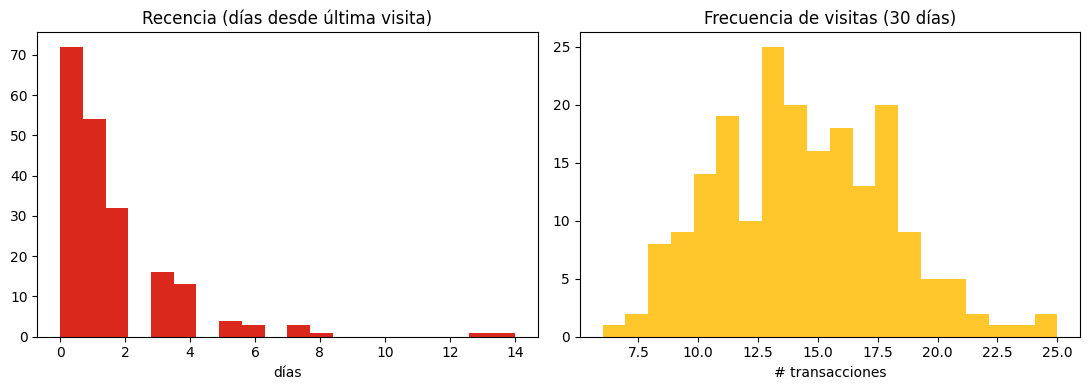

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(gold["recencia_dias"], bins=20, color="#DA291C")
axes[0].set_title("Recencia (días desde última visita)")
axes[0].set_xlabel("días")

axes[1].hist(gold["frecuencia_visitas"], bins=20, color="#FFC72C")
axes[1].set_title("Frecuencia de visitas (30 días)")
axes[1].set_xlabel("# transacciones")

plt.tight_layout()
plt.show()


## 7. Conclusión del POC

La réplica en miniatura confirma que el pipeline **extracción → limpieza → filtrado/reglas →
agregación** es suficiente para reproducir de forma auditable la lógica central del programa de
puntos, incluyendo sus exclusiones de negocio más sensibles (delivery de terceros) y bonos
especiales (bienvenida). Las variables agregadas en la capa Gold (`saldo_puntos`,
`recencia_dias`, `frecuencia_visitas`, `ticket_promedio`) son exactamente el tipo de insumo que
alimentaría los modelos propuestos en el documento de integración de ML/AI/LLM.
